# 08 - EDA con fuentes externas

**Objetivo.** Responder, con la base enriquecida por los notebooks 06 y 07, las preguntas descriptivas y diagnósticas del proyecto y reunir la primera evidencia sobre cada hipótesis. Este notebook explora y no confirma: los resultados son asociaciones observadas en un corte transversal, con unidades de análisis distintas según la pregunta.

**Cadena de trabajo de cada bloque:** pregunta -> datos y unidad -> control aplicado -> resultado -> interpretación -> conclusión parcial.

| Bloque | Pregunta | Unidad |
|---|---|---|
| 2 | ¿Cómo se distribuyen las tres operaciones en el territorio? | comuna y barrio |
| 3 | ¿Qué precios y tipologías predominan en cada operación? | publicación y barrio |
| 4 | ¿Cómo se distribuyen los servicios, el transporte y la demografía? | barrio y comuna |
| 5 | **H1** - atractivo turístico y alquiler temporario | barrio (48) y comuna (15) |
| 6 | **H2a** y **H2b** - demografía, servicios y oferta | comuna (15) |
| 7 | **H3** - transporte y precio | publicación (~45.000) |
| 8 | **H4** - alquiler temporario y alquiler permanente | comuna (15) y barrio (25) |
| 9 | Síntesis | - |

**Cómo leer la evidencia.** Las correlaciones son de Spearman (no suponen linealidad ni normalidad y toleran extremos), con intervalo de confianza del 95% por bootstrap. Un punto relleno en los gráficos indica que el intervalo no incluye al cero; uno hueco, que sí lo incluye. Con 15 comunas el poder estadístico es bajo: un intervalo ancho es información, no un defecto del gráfico.

## 1. Configuración e ingesta

In [1]:
from pathlib import Path
import json
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from IPython.display import display


def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'data' / 'raw').exists() and (path / 'README.md').exists():
            return path
    raise FileNotFoundError('No se encontró la raíz del repo. Ejecutar dentro del proyecto.')


sys.path.insert(0, str(find_repo_root()))
from src import config, geo, eda

warnings.filterwarnings('ignore', category=FutureWarning)
eda.estilo()
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

OPS = ['venta', 'alquiler', 'alquiler_temporal']
N_MINIMO = 30      # publicaciones mínimas por celda para reportar medianas o proporciones
N_BOOT = 2000      # remuestreos para los intervalos de confianza
SEED = 42
REPORTS = config.REPORTS_DIR

In [2]:
base = pd.read_csv(config.PROCESSED_DIR / 'df_publicaciones_enriquecidas_v1.csv', low_memory=False,
                   dtype={'id_publicacion': str}, parse_dates=['fecha_precio'])
kb = pd.read_csv(config.PROCESSED_DIR / 'kpis_barrio_v1.csv')
kc = pd.read_csv(config.PROCESSED_DIR / 'kpis_comuna_v1.csv')
ctx = pd.read_csv(config.PROCESSED_DIR / 'features_contextuales_barrio_v1.csv')
barrios = geo.cargar_barrios(config.EXTERNAS_RAW_DIR / 'barrios.geojson')

assert not base.duplicated(['id_publicacion', 'tipo_operacion_norm']).any(), 'clave publicación-operación no única'
print('Publicaciones:', base.shape, '| barrios:', len(kb), '| comunas:', len(kc))

Publicaciones: (67887, 90) | barrios: 48 | comunas: 15


**Fecha de corte.** Los avisos son de agosto y septiembre de 2026, las fuentes de BA Data se descargaron el 4/10/2026, el Censo es de 2022 y el dólar MEP se aplicó a la fecha de cada aviso. Los precios de Airbnb son cotizaciones para 30 noches con inicio el 20/10/2026, para dos huéspedes.

In [3]:
corte_portales = base.groupby('fuente_norm')['fecha_precio'].agg(primera='min', ultima='max').assign(
    primera=lambda d: d['primera'].dt.date, ultima=lambda d: d['ultima'].dt.date)
meta = json.loads((config.EXTERNAS_RAW_DIR / '_metadata_descarga.json').read_text(encoding='utf-8'))
corte_externas = pd.Series({k: v['fecha_descarga_utc'][:10] for k, v in meta.items()}, name='descarga')
display(corte_portales)
print('Fuentes externas descargadas el:', sorted(corte_externas.unique()))

,primera,ultima
fuente_norm,,
airbnb,2026-09-05,2026-09-06
argenprop,2026-08-15,2026-09-03
mercado_libre,2026-08-15,2026-09-05
zonaprop,2026-08-17,2026-09-03


Fuentes externas descargadas el: ['2026-10-04']


In [4]:
terr = base[base['en_alcance_territorial']].copy()
universo = pd.DataFrame({
    'filas': [len(base), int(base['en_alcance'].sum()), len(terr)],
}, index=['base enriquecida', 'en alcance (dentro de CABA)', 'en alcance con barrio oficial (universo territorial)'])
universo['pct'] = (100 * universo['filas'] / len(base)).round(1)
display(universo)

,filas,pct
base enriquecida,67887,100.0
en alcance (dentro de CABA),67874,100.0
en alcance con barrio oficial (universo territorial),67692,99.7


**Universo.** Los bloques 2 a 6 y 8 trabajan sobre el universo territorial: avisos dentro de CABA con barrio oficial asignado (el 99,7% de la base). El bloque 7 usa un subconjunto más exigente (con coordenadas, precio por m², superficie y ambientes) que se describe allí. Los avisos que aparecen a la vez en dos operaciones (alquiler y temporario, sobre todo) se conservan en ambas.

## 2. ¿Cómo se distribuyen las tres operaciones en el territorio?

**Datos.** Avisos del universo territorial por comuna y barrio. **Control.** Se compara la participación de cada comuna dentro de cada operación (qué porcentaje de todos los alquileres está en la comuna) y no la proporción entre operaciones dentro de la comuna: en la base hay 4 avisos de venta por cada alquiler, y esa relación depende de cuántas páginas se extrajeron de cada búsqueda, no del mercado.

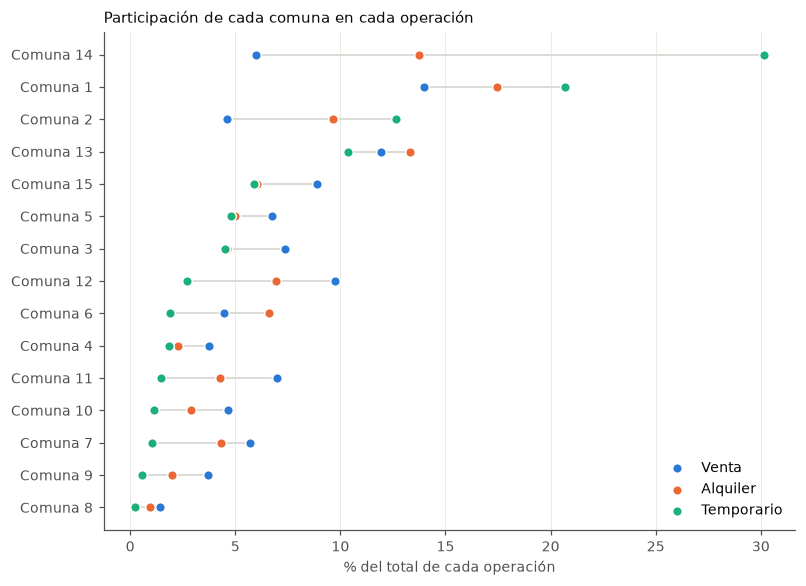

In [5]:
conteo = terr.pivot_table(index='comuna_oficial', columns='tipo_operacion_norm', values='id_publicacion',
                          aggfunc='size', fill_value=0)[OPS]
share = 100 * conteo / conteo.sum()
orden = share['alquiler_temporal'].sort_values().index
y = np.arange(len(orden))

fig, ax = plt.subplots(figsize=(7.4, 5.4))
ax.hlines(y, share.loc[orden].min(axis=1), share.loc[orden].max(axis=1), color='#d9d8d3', lw=1.2, zorder=1)
for op in OPS:
    ax.scatter(share.loc[orden, op], y, s=40, color=eda.COLOR_OPERACION[op], edgecolor='white', linewidth=1,
               label=eda.NOMBRE_OPERACION[op], zorder=3)
ax.set_yticks(y)
ax.set_yticklabels([f'Comuna {int(c)}' for c in orden])
ax.set_xlabel('% del total de cada operación')
ax.set_title('Participación de cada comuna en cada operación')
ax.legend(loc='lower right')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

In [6]:
por_barrio = terr.pivot_table(index='barrio_oficial', columns='tipo_operacion_norm', values='id_publicacion',
                              aggfunc='size', fill_value=0)[OPS]
top5 = pd.concat({eda.NOMBRE_OPERACION[op]: (100 * por_barrio[op].nlargest(5) / por_barrio[op].sum()).round(1)
                  for op in OPS}, axis=1)
display(top5.fillna(''))
airbnb_barrio = terr[terr['fuente_norm'] == 'airbnb']['barrio_oficial'].value_counts(normalize=True)
print(f"Los tres barrios con más Airbnb concentran el {100 * airbnb_barrio.head(3).sum():.1f}% de sus avisos "
      f"({', '.join(airbnb_barrio.head(3).index)}).")
display(share.round(1).rename(columns=eda.NOMBRE_OPERACION).assign(comuna=lambda d: d.index.astype(int)).set_index('comuna')
        .sort_values('Temporario', ascending=False).head(6))
share.round(2).rename(columns=eda.NOMBRE_OPERACION).to_csv(REPORTS / 'eda08_participacion_comuna_por_operacion.csv')

,Venta,Alquiler,Temporario
barrio_oficial,,,
Palermo,6.0,13.7,30.1
Balvanera,5.3,,
Almagro,5.1,,
Belgrano,4.9,7.1,5.0
Recoleta,4.6,9.7,12.7
Caballito,,6.6,
Puerto Madero,,5.8,
San Nicolas,,,5.6
Retiro,,,4.5


Los tres barrios con más Airbnb concentran el 53.7% de sus avisos (Palermo, Recoleta, San Nicolas).


tipo_operacion_norm,Venta,Alquiler,Temporario
comuna,,,
14,6.0,13.7,30.1
1,14.0,17.4,20.7
2,4.6,9.7,12.7
13,11.9,13.3,10.4
15,8.9,6.0,5.9
5,6.8,5.0,4.8


**Interpretación.** La oferta de venta está repartida: ningún barrio supera el 6% del total y la comuna con más avisos (la 1) tiene el 14%. El alquiler permanente se concentra algo más (Palermo 13,7%, Recoleta 9,7%). El temporario es la operación más concentrada: Palermo, que es la comuna 14 completa, aporta el 30,1% de los avisos y, sumada la comuna 1 y la 2, se llega a casi dos tercios. En Airbnb solo, tres barrios reúnen el 54% de los avisos. En el otro extremo, la comuna 8 es la menos representada en las tres operaciones (1,4% de la venta, 1,0% del alquiler y 0,2% del temporario).

**Conclusión parcial.** Las tres operaciones no se distribuyen igual en el territorio: el alquiler temporario sigue un patrón mucho más concentrado en el norte y el centro que la venta. Es el primer indicio a favor de H1, que se evalúa en el bloque 5. Se trata de oferta publicada: una comuna con pocos avisos puede ser una comuna con poca cobertura de los portales y no necesariamente con poca oferta real.

## 3. ¿Qué precios y tipologías predominan en cada operación?

**Datos.** Precios en USD (dólar MEP del día de extracción), precio por m² y por ambiente construidos en el notebook 07. **Control.** Se excluyen de los estadísticos los valores fuera del rango plausible de cada variable (menos del 1%); el temporario se reporta separado por fuente, porque Airbnb y Mercado Libre miden cosas distintas (30 noches para dos huéspedes sin tarifas vs. precio mensual publicado).

In [7]:
def serie(op, var, flag, fuente=None):
    s = terr[terr['tipo_operacion_norm'] == op]
    if fuente:
        s = s[s['fuente_norm'] == fuente]
    return s.loc[~s[flag], var]


F_M2, F_MES, F_VTA = 'precio_m2_usd_fuera_rango_flag', 'precio_mensual_usd_fuera_rango_flag', 'precio_venta_usd_fuera_rango_flag'
series = {
    'Venta: USD/m²': serie('venta', 'precio_m2_usd', F_M2),
    'Alquiler: USD/m²/mes': serie('alquiler', 'precio_m2_usd', F_M2),
    'Alquiler: USD/mes': serie('alquiler', 'precio_mensual_usd', F_MES),
    'Temporario MeLi: USD/mes': serie('alquiler_temporal', 'precio_mensual_usd', F_MES, 'mercado_libre'),
    'Airbnb 30 noches: USD': serie('alquiler_temporal', 'precio_mensual_usd', F_MES, 'airbnb'),
    'Venta: USD por ambiente': serie('venta', 'precio_por_ambiente_usd', F_VTA),
    'Alquiler: USD/mes por ambiente': serie('alquiler', 'precio_por_ambiente_usd', F_MES),
}
resumen_precios = pd.DataFrame({k: eda.describir(v) for k, v in series.items()}).T.round(2)
display(resumen_precios)
resumen_precios.to_csv(REPORTS / 'eda08_resumen_precios.csv')

,n,media,mediana,desvio,p10,p25,p75,p90,asimetria,cv
Venta: USD/m²,43130.0,2976.42,2717.39,1404.11,1586.93,2071.43,3500.00,4569.48,2.03,0.47
Alquiler: USD/m²/mes,10293.0,15.69,13.87,6.74,9.83,11.49,17.64,24.00,2.15,0.43
Alquiler: USD/mes,10385.0,962.58,586.24,1148.93,380.25,445.81,977.07,1900.00,4.90,1.19
Temporario MeLi: USD/mes,4098.0,1014.75,750.00,953.47,419.59,550.00,1200.00,1779.10,5.54,0.94
Airbnb 30 noches: USD,9400.0,2427.57,1811.50,2034.94,1113.90,1367.75,2676.25,4124.10,3.76,0.84
Venta: USD por ambiente,42787.0,83488.37,68933.33,71413.47,32500.00,45332.50,96666.67,138000.00,6.20,0.86
Alquiler: USD/mes por ambiente,10098.0,441.21,358.26,322.30,196.68,245.85,500.00,760.00,3.24,0.73


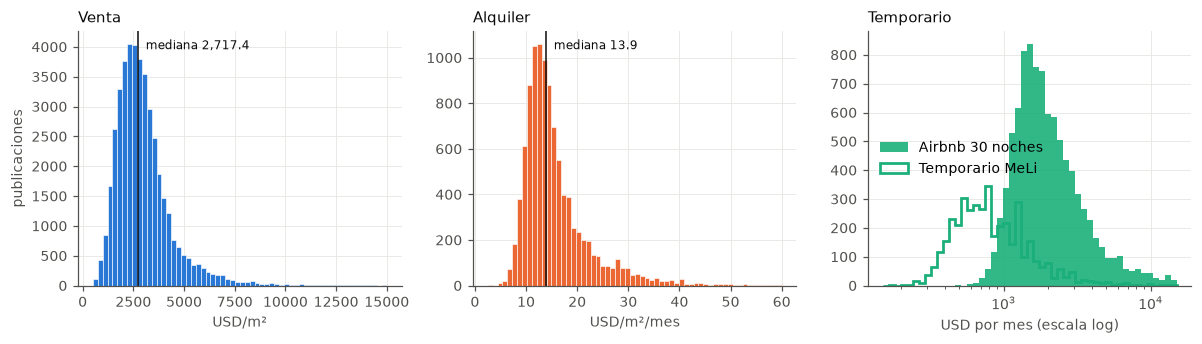

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, (clave, op) in zip(axes[:2], [('Venta: USD/m²', 'venta'), ('Alquiler: USD/m²/mes', 'alquiler')]):
    v = series[clave]
    ax.hist(v, bins=60, color=eda.COLOR_OPERACION[op], edgecolor='white', linewidth=0.4)
    ax.axvline(v.median(), color=eda.TEXTO, lw=1)
    ax.text(v.median(), ax.get_ylim()[1] * 0.93, f'  mediana {v.median():,.1f}', fontsize=8, color=eda.TEXTO)
    ax.set_xlabel(clave.split(': ')[1])
    ax.set_title(clave.split(': ')[0])
ax = axes[2]
bins = np.logspace(np.log10(150), np.log10(15000), 50)
for clave, estilo in [('Airbnb 30 noches: USD', dict(histtype='stepfilled', alpha=0.9)),
                      ('Temporario MeLi: USD/mes', dict(histtype='step', linewidth=1.8))]:
    ax.hist(series[clave], bins=bins, color=eda.COLOR_OPERACION['alquiler_temporal'], label=clave.split(': ')[0], **estilo)
ax.set_xscale('log')
ax.set_xlabel('USD por mes (escala log)')
ax.set_title('Temporario')
ax.legend()
axes[0].set_ylabel('publicaciones')
plt.tight_layout()
plt.show()

**Interpretación.** Las distribuciones de precio por m² son asimétricas a la derecha (cola de unidades de alta gama), con mediana de USD 2.717 por m² en venta y de unos USD 14 por m² al mes en alquiler. Por eso la mediana, y no la media, es el estadístico de referencia. La comparación de las dos fuentes de temporario es la más importante del bloque: el precio mensual mediano de Airbnb (USD 1.812) es 2,4 veces el de Mercado Libre temporario (USD 750), y sus rangos intercuartílicos ni siquiera se tocan (el 75% de los avisos de Mercado Libre cuesta menos que el 75% de los de Airbnb). No son dos muestras de lo mismo: Airbnb ofrece unidades amobladas orientadas al turismo y cotizadas para 30 noches con dos huéspedes, mientras que gran parte del "temporario" de Mercado Libre se parece a un alquiler permanente con contrato corto. Elegir una u otra fuente cambia la magnitud de cualquier brecha con el alquiler permanente (bloque 8).

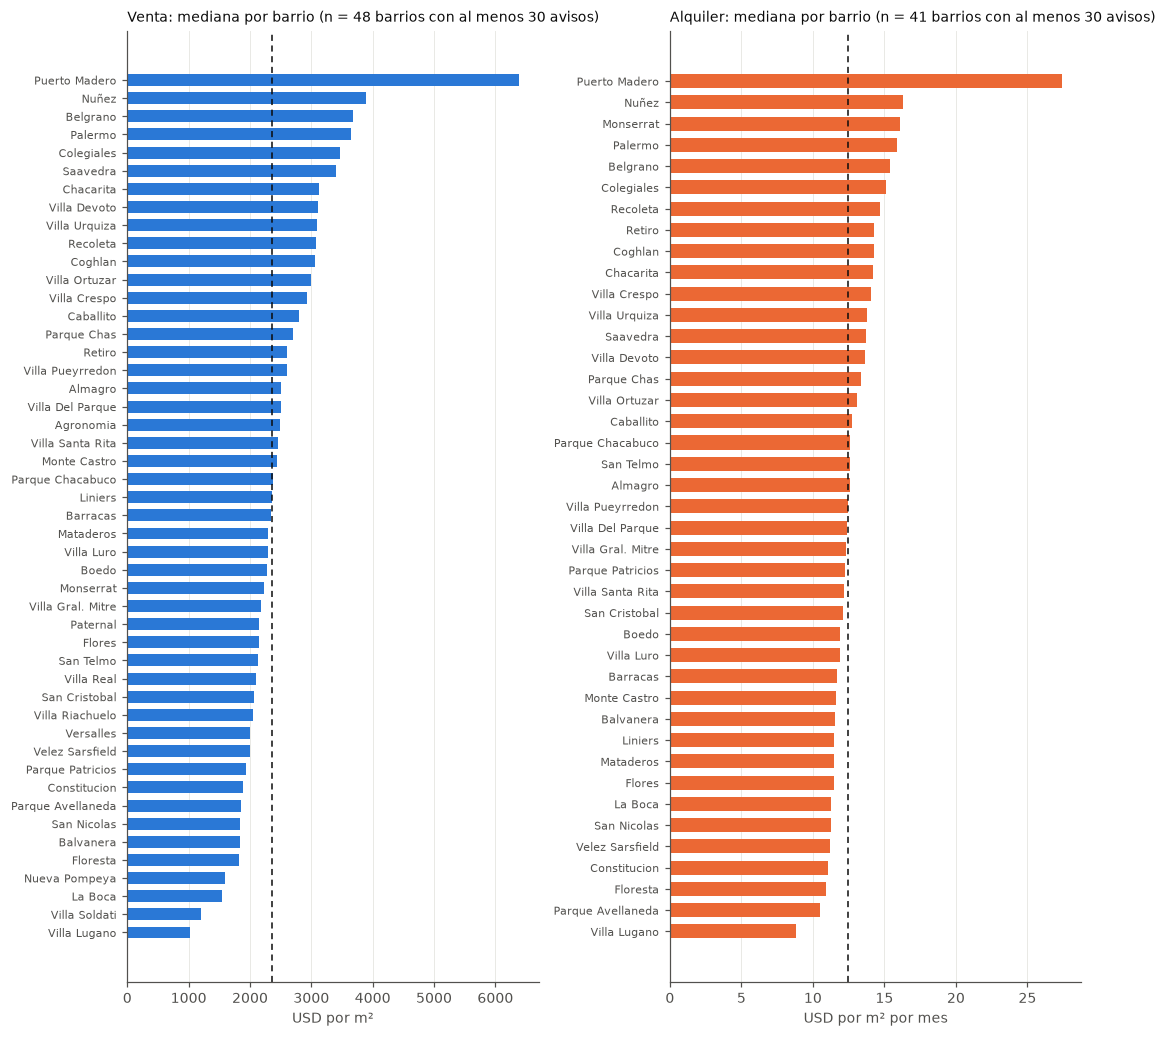

,barrio más barato,mínimo,barrio más caro,máximo,máximo / mínimo
mediana_precio_m2_venta_usd,Villa Lugano,1016.326531,Puerto Madero,6387.354701,6.284747
mediana_precio_m2_alquiler_usd,Villa Lugano,8.830648,Puerto Madero,27.39726,3.10252


Spearman entre barrios, precio por m² de venta vs. de alquiler: 0.86 (n = 41)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 9.5))
for ax, (col, op, unidad) in zip(axes, [('mediana_precio_m2_venta_usd', 'venta', 'USD por m²'),
                                         ('mediana_precio_m2_alquiler_usd', 'alquiler', 'USD por m² por mes')]):
    s = kb.set_index('barrio_oficial')[col].dropna().sort_values()
    ax.barh(s.index, s.values, color=eda.COLOR_OPERACION[op], height=0.66)
    ax.axvline(s.median(), color=eda.TEXTO, lw=1, ls=(0, (4, 3)))
    ax.set_title(f'{eda.NOMBRE_OPERACION[op]}: mediana por barrio (n = {len(s)} barrios con al menos {N_MINIMO} avisos)', fontsize=9)
    ax.set_xlabel(unidad)
    ax.tick_params(axis='y', labelsize=7.5)
    ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

rango = pd.DataFrame({c: {'barrio más barato': kb.loc[kb[c].idxmin(), 'barrio_oficial'], 'mínimo': kb[c].min(),
                          'barrio más caro': kb.loc[kb[c].idxmax(), 'barrio_oficial'], 'máximo': kb[c].max(),
                          'máximo / mínimo': kb[c].max() / kb[c].min()}
                      for c in ['mediana_precio_m2_venta_usd', 'mediana_precio_m2_alquiler_usd']}).T
display(rango)
corr = eda.spearman_boot(kb['mediana_precio_m2_venta_usd'], kb['mediana_precio_m2_alquiler_usd'], N_BOOT, SEED)
print(f"Spearman entre barrios, precio por m² de venta vs. de alquiler: {corr['rho']:.2f} (n = {corr['n']})")

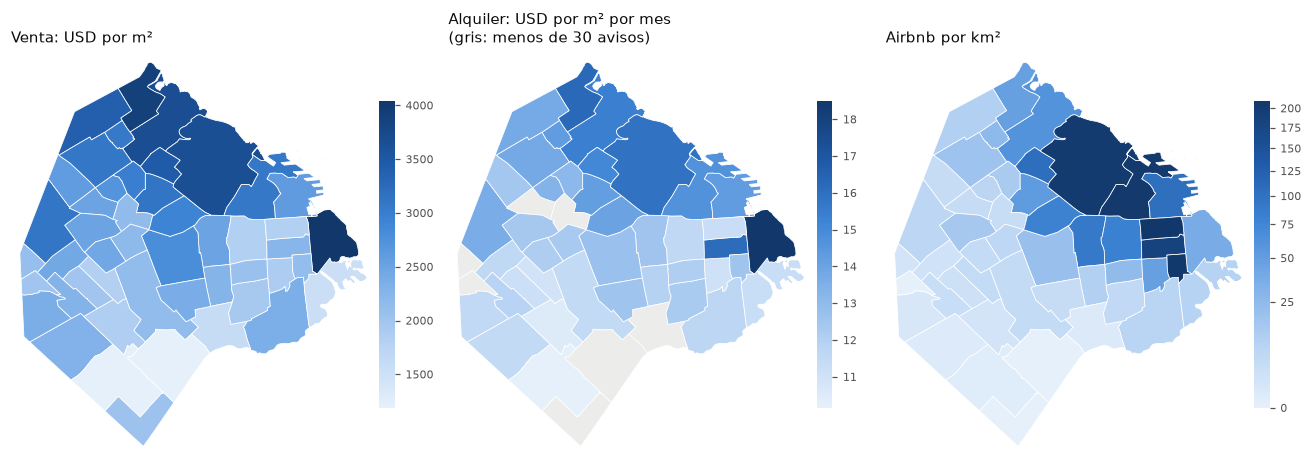

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.6))
v_m2 = kb.set_index('barrio_oficial')
mapas = [('mediana_precio_m2_venta_usd', 'Venta: USD por m²', None),
         ('mediana_precio_m2_alquiler_usd', 'Alquiler: USD por m² por mes\n(gris: menos de 30 avisos)', None),
         ('airbnb_por_km2', 'Airbnb por km²', PowerNorm(0.5, vmin=0, vmax=kb['airbnb_por_km2'].quantile(0.98)))]
for ax, (col, titulo, norm) in zip(axes, mapas):
    eda.mapa_barrios(ax, barrios, v_m2[col], titulo, norm=norm, fmt='{:,.0f}')
plt.tight_layout()
plt.show()

**Interpretación.** El precio por m² de venta varía 6,3 veces entre barrios (de USD 1.016 en Villa Lugano a USD 6.387 en Puerto Madero) y el de alquiler 3,1 veces. Los dos ordenan los barrios de forma casi idéntica (Spearman 0,86): los barrios caros para comprar lo son para alquilar. El gradiente es el esperable en la ciudad, con los valores altos en el corredor norte y la franja ribereña y los bajos en el sur y el oeste. La venta se dispersa más que el alquiler, es decir que la diferencia entre barrios se amplifica al comprar. El mapa de Airbnb por km² dibuja el mismo corredor pero más angosto: la oferta temporaria se concentra en un subconjunto de los barrios caros.

**Conclusión parcial.** La ubicación explica buena parte de la dispersión de precios, y dos de las tres operaciones comparten ese mapa de precios. La posición del temporario es distinta y depende de la fuente.

ambientes_cat,1,2,3,4 o más
tipo_operacion_norm,,,,
Venta,21.6,30.7,27.6,20.1
Alquiler,29.1,39.7,20.1,11.1
Temporario,32.8,40.8,19.4,6.9


Excluye Airbnb: allí los ambientes se derivan (dormitorios + 1) y no son comparables.


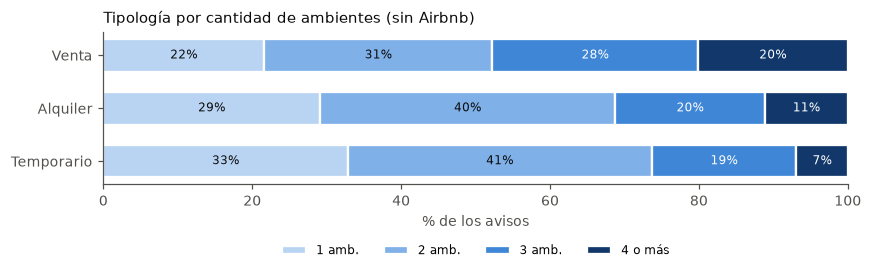

In [11]:
amb = terr[(terr['fuente_norm'] != 'airbnb') & terr['ambientes_ref'].notna()].copy()
amb['ambientes_cat'] = amb['ambientes_ref'].clip(upper=4).astype(int).astype(str).replace({'4': '4 o más'})
comp = pd.crosstab(amb['tipo_operacion_norm'], amb['ambientes_cat'], normalize='index').mul(100).loc[OPS]
display(comp.round(1).rename(index=eda.NOMBRE_OPERACION))
print('Excluye Airbnb: allí los ambientes se derivan (dormitorios + 1) y no son comparables.')

fig, ax = plt.subplots(figsize=(8, 2.8))
colores = ['#b9d4f3', '#7fb0e8', '#3f86d6', '#12386b']
izq = np.zeros(len(comp))
for col, c in zip(comp.columns, colores):
    ax.barh([eda.NOMBRE_OPERACION[o] for o in comp.index], comp[col], left=izq, color=c, edgecolor='white', linewidth=1.5,
            label=f'{col} amb.' if col != '4 o más' else '4 o más', height=0.62)
    for i, (l, w) in enumerate(zip(izq, comp[col])):
        if w > 6:
            ax.text(l + w / 2, i, f'{w:.0f}%', ha='center', va='center', fontsize=8,
                    color=eda.TEXTO if c in ('#b9d4f3', '#7fb0e8') else 'white')
    izq += comp[col].to_numpy()
ax.set_xlim(0, 100)
ax.invert_yaxis()
ax.set_xlabel('% de los avisos')
ax.set_title('Tipología por cantidad de ambientes (sin Airbnb)')
ax.legend(ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.32), fontsize=8)
ax.grid(False)
plt.tight_layout()
plt.show()
comp.round(2).to_csv(REPORTS / 'eda08_composicion_ambientes.csv')

**Interpretación.** La oferta de alquiler y de temporario se concentra en unidades chicas: el 69% y el 74% de los avisos tiene uno o dos ambientes, contra el 52% en venta. La venta, en cambio, tiene presencia importante de tres y cuatro o más ambientes (casi la mitad), lo que sugiere que se vende para vivir en familia y se alquila para vivir solo o en pareja. Hay que recordar que Mercado Libre solo trae departamentos, así que esta tipología describe departamentos y no la oferta de casas y PH.

## 4. ¿Cómo se distribuyen los servicios, el transporte y la demografía?

**Datos.** Densidades por km² de cada fuente de BA Data en los 48 barrios (notebook 06) y variables del Censo 2022 en las 15 comunas. **Control.** Los puntos de cada fuente se asignaron al barrio por polígono, con la misma regla que las publicaciones.

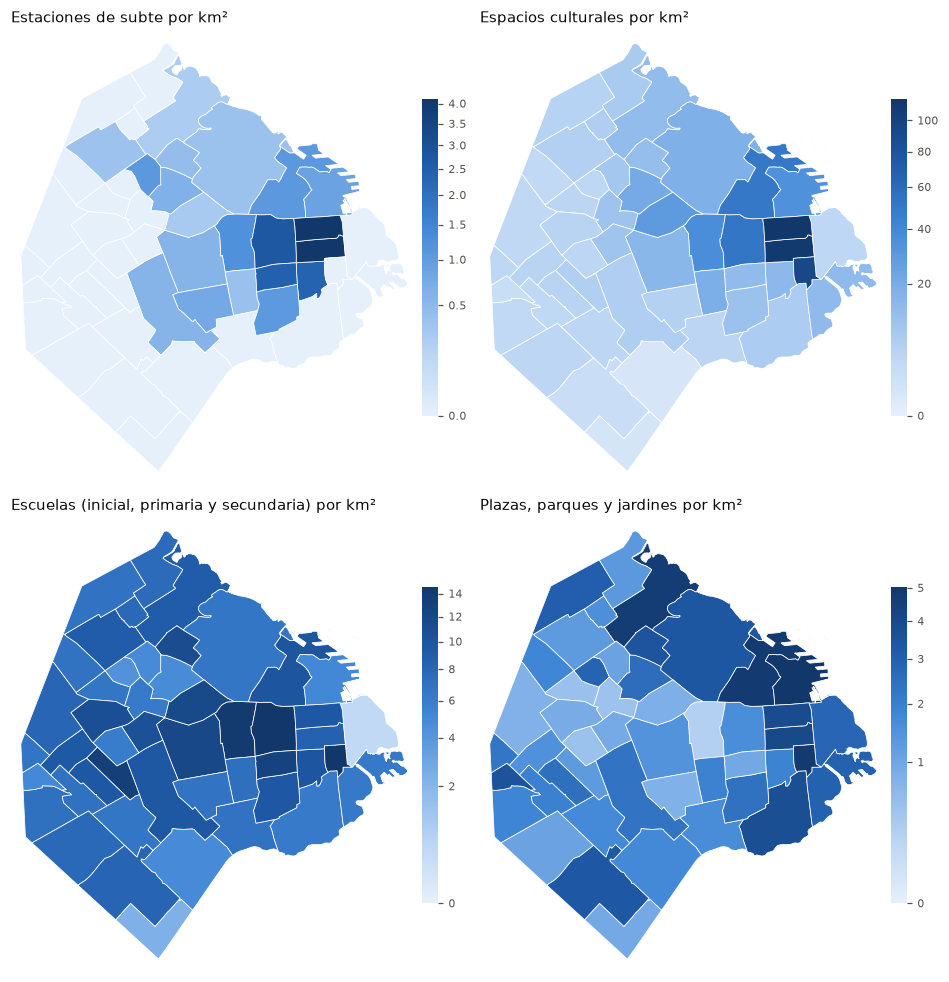

,total de puntos,barrios sin ningún punto
n_subte,90,28
n_tren,43,21
n_metrobus,390,15
n_hospitales,36,29
n_educacion,1627,0
n_culturales,3031,0
n_gastronomia,2823,1
n_espacios_verdes,485,0


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(8.8, 9))
for ax, (col, titulo) in zip(axes.flat, [('densidad_subte_km2', 'Estaciones de subte por km²'),
                                         ('densidad_culturales_km2', 'Espacios culturales por km²'),
                                         ('densidad_educacion_km2', 'Escuelas (inicial, primaria y secundaria) por km²'),
                                         ('densidad_espacios_verdes_km2', 'Plazas, parques y jardines por km²')]):
    eda.mapa_barrios(ax, barrios, kb.set_index('barrio_oficial')[col], titulo,
                     norm=PowerNorm(0.5, vmin=0, vmax=kb[col].quantile(0.98)))
plt.tight_layout()
plt.show()
resumen_serv = ctx[['barrio_oficial'] + [c for c in ctx.columns if c.startswith('n_')]].set_index('barrio_oficial')
display(pd.DataFrame({'total de puntos': resumen_serv.sum(), 'barrios sin ningún punto': (resumen_serv == 0).sum()}))

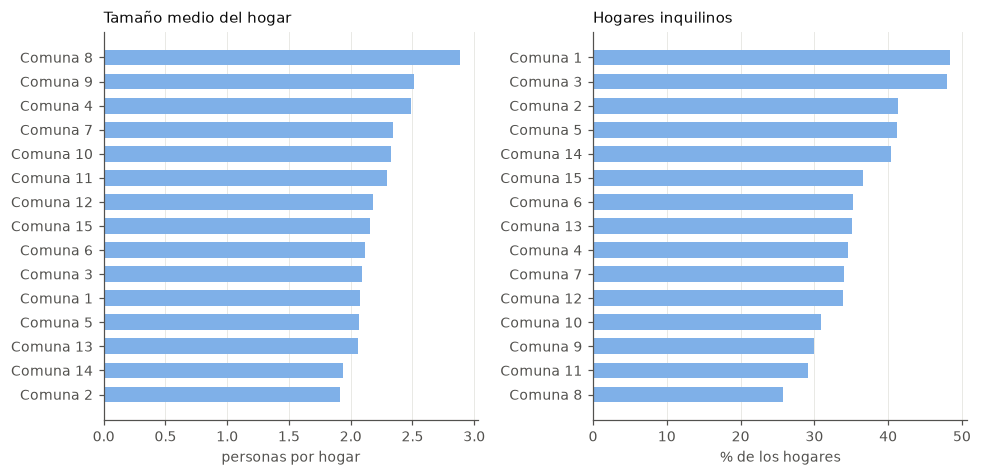

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.4))
for ax, (col, titulo, unidad) in zip(axes, [('tamano_medio_hogar', 'Tamaño medio del hogar', 'personas por hogar'),
                                             ('pct_hogares_inquilinos', 'Hogares inquilinos', '% de los hogares')]):
    s = kc.set_index('comuna')[col].sort_values()
    ax.barh([f'Comuna {int(i)}' for i in s.index], s.values, color='#7fb0e8', height=0.66)
    ax.set_title(titulo)
    ax.set_xlabel(unidad)
    ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

**Interpretación.** Los servicios no se reparten parejo. El subte está en 20 de los 48 barrios y se concentra en el centro y el eje norte; el MetroBus cubre 33 y el tren 27 (siempre dentro de CABA). La oferta cultural es la más concentrada de todas, con densidad muy alta en el centro y en Palermo. Las escuelas están en los 48 barrios y siguen el mapa de población, mientras que los hospitales públicos (36 en toda la ciudad) están ausentes de la mayoría. Los espacios verdes están en los 48 barrios.

En la demografía hay un gradiente: las comunas del centro y el norte (1, 2, 3, 14) tienen hogares más chicos (menos de 2,1 personas) y más hogares inquilinos (40% a 48%), mientras que la comuna 8 es el opuesto (2,9 personas por hogar y 26% de inquilinos). Servicios, transporte, oferta turística y composición de los hogares están correlacionados entre sí, porque todos reflejan la misma centralidad. Esto limita lo que se puede concluir de cualquier asociación bivariada de los bloques siguientes.

## 5. H1 - Atractivo turístico y alquiler temporario

**Hipótesis.** Los barrios con mayor atractivo turístico y cultural tienen una mayor densidad de alojamientos temporarios completos.

**Datos y unidad.** Barrio (48 unidades). Variable de resultado: avisos de Airbnb sobre avisos de alquiler permanente del barrio. **Control.** La versión directa (Airbnb por km² contra densidad por km²) comparte el denominador de superficie en los dos lados y se inflaría por construcción; por eso se usa una razón que no depende del tamaño del barrio. Como comprobación independiente se repite en las 15 comunas con Airbnb por 1.000 viviendas del Censo.

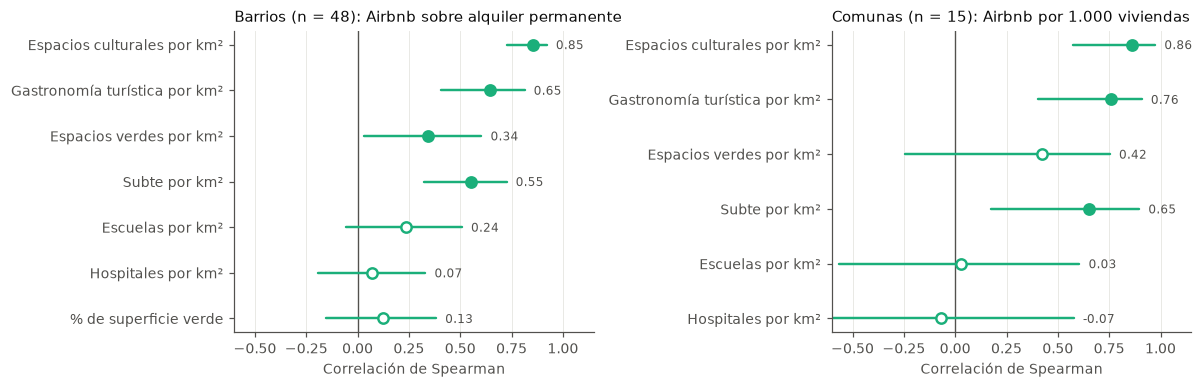

variable    rho     lo     hi      p   n
barrio 0    Espacios culturales por km²  0.855  0.729  0.921  0.000  48
       1  Gastronomía turística por km²  0.646  0.405  0.813  0.000  48
       2        Espacios verdes por km²  0.344  0.029  0.603  0.017  48
       3                  Subte por km²  0.555  0.321  0.725  0.000  48
       4               Escuelas por km²  0.237 -0.055  0.508  0.105  48
       5             Hospitales por km²  0.072 -0.195  0.330  0.628  48
       6          % de superficie verde  0.126 -0.152  0.382  0.395  48
comuna 0    Espacios culturales por km²  0.861  0.575  0.974  0.000  15
       1  Gastronomía turística por km²  0.761  0.406  0.909  0.001  15
       2        Espacios verdes por km²  0.421 -0.245  0.753  0.118  15
       3                  Subte por km²  0.650  0.176  0.896  0.009  15
       4               Escuelas por km²  0.029 -0.566  0.605  0.919  15
       5             Hospitales por km² -0.068 -0.656  0.578  0.810  15

In [14]:
kbh = kb.set_index('barrio_oficial').copy()
kbh['airbnb_sobre_alquiler'] = kbh['n_airbnb'] / kbh['n_alquiler'].replace(0, np.nan)

SERVICIOS = {'culturales': 'Espacios culturales', 'gastronomia': 'Gastronomía turística', 'espacios_verdes': 'Espacios verdes',
             'subte': 'Subte', 'educacion': 'Escuelas', 'hospitales': 'Hospitales'}
etq_barrio = {f'densidad_{k}_km2': f'{v} por km²' for k, v in SERVICIOS.items()}
etq_barrio['pct_superficie_verde'] = '% de superficie verde'
h1_barrio = eda.tabla_spearman(kbh, 'airbnb_sobre_alquiler', list(etq_barrio), etq_barrio, n_boot=N_BOOT, seed=SEED)

agg = ctx.groupby('comuna')[['area_km2'] + [f'n_{k}' for k in SERVICIOS]].sum()
for k in SERVICIOS:
    agg[f'dens_{k}'] = agg[f'n_{k}'] / agg['area_km2']
kcx = kc.set_index('comuna').join(agg)
etq_comuna = {f'dens_{k}': f'{v} por km²' for k, v in SERVICIOS.items()}
h1_comuna = eda.tabla_spearman(kcx, 'airbnb_por_1000_viviendas', list(etq_comuna), etq_comuna, n_boot=N_BOOT, seed=SEED)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)
for ax, tabla, titulo in [(axes[0], h1_barrio, f'Barrios (n = 48): Airbnb sobre alquiler permanente'),
                          (axes[1], h1_comuna, 'Comunas (n = 15): Airbnb por 1.000 viviendas')]:
    eda.forest(ax, tabla, color=eda.COLOR_OPERACION['alquiler_temporal'])
    ax.set_title(titulo, fontsize=9.5)
axes[0].set_xlim(-0.6, 1.15)
plt.tight_layout()
plt.show()
display(pd.concat({'barrio': h1_barrio, 'comuna': h1_comuna}).round(3))
pd.concat({'barrio': h1_barrio, 'comuna': h1_comuna}).round(4).to_csv(REPORTS / 'eda08_h1_correlaciones.csv')

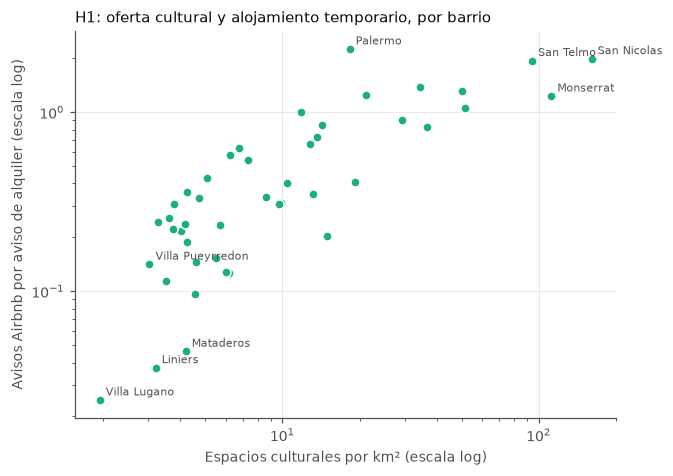

In [15]:
fig, ax = plt.subplots(figsize=(6.2, 4.4))
d = kbh[['airbnb_sobre_alquiler', 'densidad_culturales_km2']].replace(0, np.nan).dropna()
ax.scatter(d['densidad_culturales_km2'], d['airbnb_sobre_alquiler'], s=36, color=eda.COLOR_OPERACION['alquiler_temporal'],
           edgecolor='white', linewidth=1, zorder=3)
ax.set_xscale('log')
ax.set_yscale('log')
eda.rotular_extremos(ax, d['densidad_culturales_km2'], d['airbnb_sobre_alquiler'], d.index, k=3)
ax.set_xlabel('Espacios culturales por km² (escala log)')
ax.set_ylabel('Avisos Airbnb por aviso de alquiler (escala log)')
ax.set_title('H1: oferta cultural y alojamiento temporario, por barrio')
plt.tight_layout()
plt.show()

**Interpretación.** La asociación es fuerte y consistente en las dos unidades. Entre barrios, la relación entre Airbnb (relativa al alquiler permanente) y la densidad de espacios culturales es de 0,85, y con la gastronomía turística de 0,65. La comprobación independiente por comuna, con un denominador distinto (viviendas del Censo), da prácticamente lo mismo (0,86 y 0,76). Los espacios verdes se asocian más débilmente (0,34 entre barrios, no distinguible de cero entre comunas), la superficie verde del barrio no se asocia, y hospitales y escuelas tienen asociaciones débiles que no se distinguen de cero. El subte también se relaciona con Airbnb (0,55): es un indicio de que parte de la señal es centralidad.

**Conclusión parcial.** Hay evidencia preliminar a favor de H1: los barrios con más oferta cultural y gastronómica tienen proporcionalmente más alojamiento temporario, y el patrón se sostiene al cambiar la unidad y la forma de normalizar. No se puede separar todavía el efecto del atractivo turístico del de la centralidad, que arrastra a la cultura, la gastronomía y el transporte a la vez. El control por centralidad queda para el análisis multivariado, y la asociación no implica causalidad.

## 6. H2a y H2b - Demografía, servicios y oferta

### H2a - Tamaño del hogar y tipología de la oferta

**Hipótesis.** Las comunas con hogares más chicos tienen mayor participación de unidades de uno y dos ambientes en la oferta. **Datos y unidad.** Comuna (15 unidades). El Censo no publica hogares unipersonales por comuna, así que se usa el tamaño medio del hogar como aproximación. **Control.** Se separa por operación, se excluye Airbnb (sus ambientes son derivados) y se exige un mínimo de 30 avisos por comuna.

,operación,comunas,avisos mín. por comuna,rho,IC95 inf.,IC95 sup.,p
0,Venta,15,613,-0.286,-0.738,0.336,0.302
1,Alquiler,15,99,0.011,-0.612,0.639,0.970
2,Temporario,15,31,-0.500,-0.857,0.065,0.058


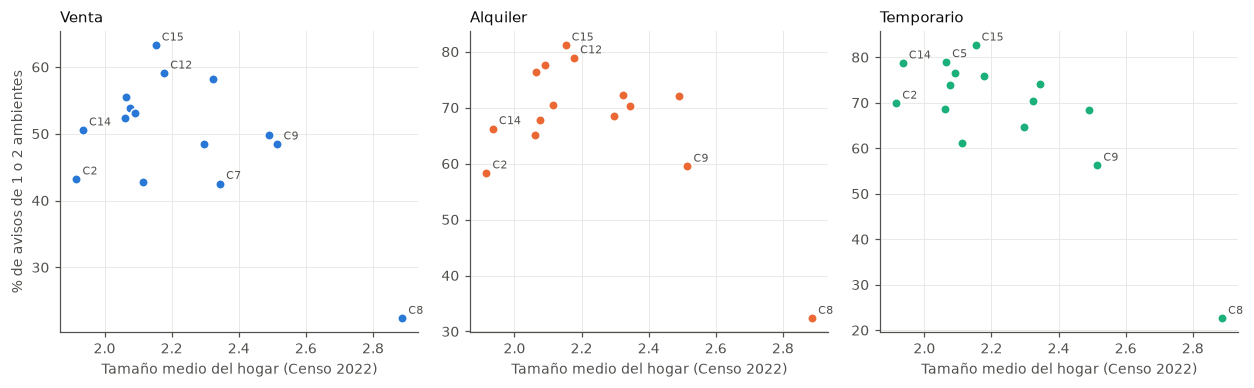

In [16]:
amb['chico'] = amb['ambientes_ref'] <= 2
filas, datos_h2a = [], {}
for op in OPS:
    g = amb[amb['tipo_operacion_norm'] == op].groupby('comuna_oficial')['chico'].agg(pct='mean', n='size')
    g = g[g['n'] >= N_MINIMO].assign(pct=lambda d: 100 * d['pct']).join(kc.set_index('comuna')['tamano_medio_hogar'])
    datos_h2a[op] = g
    r = eda.spearman_boot(g['tamano_medio_hogar'], g['pct'], N_BOOT, SEED)
    filas.append({'operación': eda.NOMBRE_OPERACION[op], 'comunas': r['n'], 'avisos mín. por comuna': int(g['n'].min()),
                  'rho': r['rho'], 'IC95 inf.': r['lo'], 'IC95 sup.': r['hi'], 'p': r['p']})
h2a = pd.DataFrame(filas).round(3)
display(h2a)
h2a.to_csv(REPORTS / 'eda08_h2a_correlaciones.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.6), sharex=True)
for ax, op in zip(axes, OPS):
    g = datos_h2a[op]
    ax.scatter(g['tamano_medio_hogar'], g['pct'], s=38, color=eda.COLOR_OPERACION[op], edgecolor='white', linewidth=1, zorder=3)
    eda.rotular_extremos(ax, g['tamano_medio_hogar'], g['pct'], g.index.astype(int), k=2, prefijo='C')
    ax.set_title(eda.NOMBRE_OPERACION[op])
    ax.set_xlabel('Tamaño medio del hogar (Censo 2022)')
axes[0].set_ylabel('% de avisos de 1 o 2 ambientes')
plt.tight_layout()
plt.show()

**Interpretación.** No hay evidencia a favor de H2a. En venta la correlación es negativa (-0,29), en el sentido esperado, pero el intervalo incluye con holgura al cero; en alquiler es nula (0,01); en temporario es -0,50, la más grande, pero con apenas 31 avisos en la comuna con menos datos y p = 0,058 no es concluyente. La participación de unidades chicas varía mucho entre comunas (de 22% a 63% en venta), pero esa variación no sigue al tamaño del hogar.

**Conclusión parcial.** Con 15 comunas y una aproximación débil al hogar unipersonal, el análisis tiene muy poco poder para detectar una asociación moderada, y no detectarla no equivale a descartarla. Además, Mercado Libre (la fuente casi exclusiva) solo trae departamentos. H2a no puede evaluarse bien con los datos actuales: requiere hogares unipersonales por barrio o comuna (por ejemplo, de la Encuesta Anual de Hogares de la Dirección de Estadística y Censos de la Ciudad).

### H2b - Servicios y concentración de oferta

**Hipótesis.** Las zonas con más servicios urbanos tienen mayor intensidad de oferta publicada. **Datos y unidad.** Comuna (15 unidades): avisos por 1.000 viviendas del Censo contra la densidad por km² de cada servicio. **Control.** Se analiza por separado alquiler y venta y por tipo de servicio. Son 12 contrastes sobre las mismas 15 comunas y los p-valores no se corrigen por comparaciones múltiples.

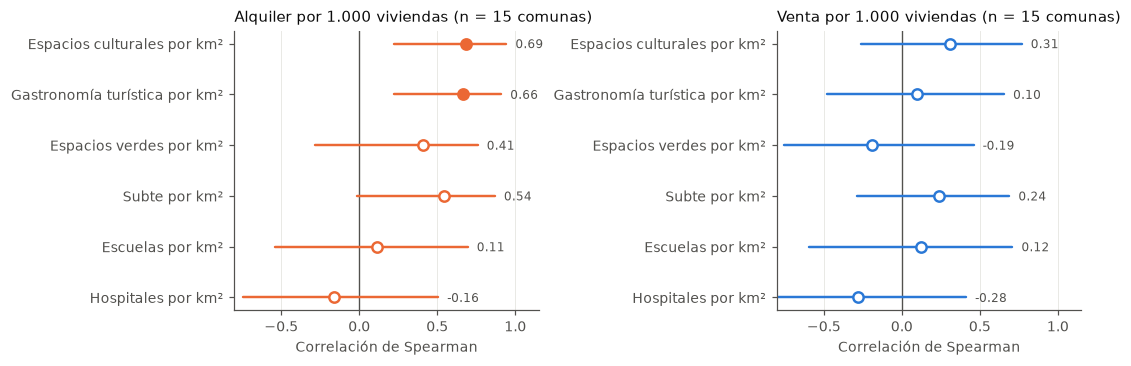

variable    rho     lo     hi      p   n
alquiler 0    Espacios culturales por km²  0.686  0.225  0.942  0.005  15
         1  Gastronomía turística por km²  0.664  0.220  0.909  0.007  15
         2        Espacios verdes por km²  0.411 -0.283  0.758  0.128  15
         3                  Subte por km²  0.544 -0.011  0.868  0.036  15
         4               Escuelas por km²  0.111 -0.539  0.695  0.694  15
         5             Hospitales por km² -0.164 -0.748  0.505  0.558  15
venta    0    Espacios culturales por km²  0.307 -0.259  0.768  0.265  15
         1  Gastronomía turística por km²  0.100 -0.481  0.655  0.723  15
         2        Espacios verdes por km² -0.189 -0.758  0.459  0.499  15
         3                  Subte por km²  0.236 -0.289  0.688  0.397  15
         4               Escuelas por km²  0.121 -0.593  0.708  0.666  15
         5             Hospitales por km² -0.282 -0.881  0.411  0.308  15

Umbral de Bonferroni para 12 contrastes: p < 0.0042


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharex=True)
h2b = {}
for ax, op, col in [(axes[0], 'alquiler', 'alquiler_por_1000_viviendas'), (axes[1], 'venta', 'venta_por_1000_viviendas')]:
    h2b[op] = eda.tabla_spearman(kcx, col, list(etq_comuna), etq_comuna, n_boot=N_BOOT, seed=SEED)
    eda.forest(ax, h2b[op], color=eda.COLOR_OPERACION[op])
    ax.set_title(f'{eda.NOMBRE_OPERACION[op]} por 1.000 viviendas (n = 15 comunas)', fontsize=9.5)
axes[0].set_xlim(-0.8, 1.15)
plt.tight_layout()
plt.show()
h2b_tabla = pd.concat(h2b).round(3)
display(h2b_tabla)
h2b_tabla.to_csv(REPORTS / 'eda08_h2b_correlaciones.csv')
print(f'Umbral de Bonferroni para 12 contrastes: p < {0.05 / 12:.4f}')

**Interpretación.** Solo una parte de los servicios se asocia con la oferta, y solo con el alquiler. La densidad de espacios culturales (0,69) y la gastronomía (0,66) acompañan al alquiler por 1.000 viviendas, y el subte (0,54) también, aunque con un intervalo que roza el cero, mientras que escuelas, hospitales y espacios verdes no muestran relación, y ningún servicio se asocia con la venta. Con 12 contrastes sobre 15 comunas, los p-valores de cultura (0,005) y gastronomía (0,007) no superan el umbral de Bonferroni (0,004): son indicios, no hallazgos firmes.

**Conclusión parcial.** H2b tiene apoyo parcial. Los servicios que se asocian son los mismos que marcan centralidad y turismo (cultura, gastronomía, subte), no los servicios básicos (escuelas, hospitales) que la hipótesis tenía en mente. La lectura más conservadora es que la oferta de alquiler es mayor donde hay más actividad urbana, y no que los servicios la atraigan. La oferta de venta no sigue ese patrón.

## 7. H3 - Transporte y precio

**Hipótesis.** Entre propiedades comparables, una menor distancia al transporte masivo se asocia con mayor precio.

**Datos y unidad.** Publicación. Avisos de venta y alquiler de Mercado Libre y ArgenProp con coordenadas geocodificadas con USIG dentro de CABA, precio por m² válido, superficie y ambientes. Airbnb queda fuera (no tiene superficie ni precio comparable). ZonaProp no tiene dirección. **Control.** Modelo log-lineal del precio por m² con efectos fijos de barrio, superficie (en logaritmo) y ambientes, con errores estándar agrupados por barrio: compara avisos del mismo barrio y descuenta que los barrios caros son distintos de los baratos. El coeficiente se lee como el cambio porcentual del precio por m² cada 100 m más lejos del transporte.

In [18]:
h3 = terr[(terr['fuente_norm'] != 'airbnb') & terr['coords_en_caba'] & terr['precio_m2_usd'].notna()
          & ~terr[F_M2] & terr['superficie_ref_m2'].notna() & terr['ambientes_ref'].notna()
          & terr['tipo_operacion_norm'].isin(['venta', 'alquiler'])].copy()
h3['lpm2'] = np.log(h3['precio_m2_usd'])
h3['lsup'] = np.log(h3['superficie_ref_m2'])
h3['amb_cat'] = h3['ambientes_ref'].clip(upper=5).astype(int).astype(str)
display(h3.groupby(['tipo_operacion_norm', 'fuente_norm']).size().rename('avisos').to_frame())

avisos
tipo_operacion_norm fuente_norm          
alquiler            argenprop          56
                    mercado_libre    8070
venta               argenprop          69
                    mercado_libre   36756

,operación,medio,efecto,lo,hi,p,n
0,venta,"Transporte masivo, sin controles",0.949,-0.707,2.604,0.261,36825
1,venta,Transporte masivo (mínimo de los tres),0.833,0.028,1.639,0.043,36825
2,venta,Subte,0.402,-0.153,0.956,0.155,36825
3,venta,Tren,0.168,-0.521,0.858,0.632,36825
4,venta,MetroBus,0.124,-0.341,0.588,0.602,36825
5,venta,Hospital,-0.339,-0.755,0.077,0.110,36825
6,venta,Espacio verde,0.141,-0.532,0.814,0.681,36825
7,alquiler,"Transporte masivo, sin controles",0.888,-0.909,2.684,0.333,8126
8,alquiler,Transporte masivo (mínimo de los tres),0.966,0.383,1.549,0.001,8126
9,alquiler,Subte,0.664,0.127,1.201,0.015,8126


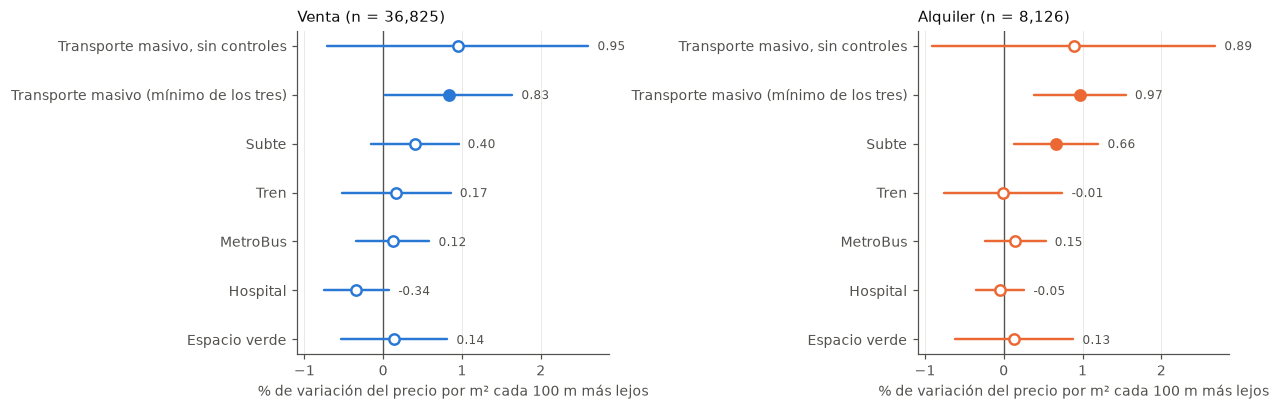

In [19]:
MEDIOS = {'dist_transporte_masivo_m': 'Transporte masivo (mínimo de los tres)', 'dist_subte_m': 'Subte', 'dist_tren_m': 'Tren',
          'dist_metrobus_m': 'MetroBus', 'dist_hospitales_m': 'Hospital', 'dist_espacio_verde_m': 'Espacio verde'}
filas = []
for op in ['venta', 'alquiler']:
    s = h3[h3['tipo_operacion_norm'] == op].copy()
    s['dm'] = s['dist_transporte_masivo_m'] / 100
    b, lo, hi, p = eda.coef_pct(eda.ols_cluster(s, 'lpm2 ~ dm', 'barrio_oficial'), 'dm')
    filas.append({'operación': op, 'medio': 'Transporte masivo, sin controles', 'efecto': b, 'lo': lo, 'hi': hi, 'p': p, 'n': len(s)})
    for col, nombre in MEDIOS.items():
        s['dm'] = s[col] / 100
        m = eda.ols_cluster(s, 'lpm2 ~ dm + lsup + C(amb_cat) + C(barrio_oficial)', 'barrio_oficial')
        b, lo, hi, p = eda.coef_pct(m, 'dm')
        filas.append({'operación': op, 'medio': nombre, 'efecto': b, 'lo': lo, 'hi': hi, 'p': p, 'n': len(s)})
h3_tabla = pd.DataFrame(filas)
display(h3_tabla.round(3))
h3_tabla.round(4).to_csv(REPORTS / 'eda08_h3_efectos.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8), sharex=True)
for ax, op in zip(axes, ['venta', 'alquiler']):
    t = h3_tabla[h3_tabla['operación'] == op].rename(columns={'medio': 'variable'})
    eda.forest(ax, t, col_valor='efecto', color=eda.COLOR_OPERACION[op], decimales=2,
               xlabel='% de variación del precio por m² cada 100 m más lejos')
    ax.set_title(f'{eda.NOMBRE_OPERACION[op]} (n = {t["n"].iloc[0]:,})', fontsize=9.5)
plt.tight_layout()
plt.show()

In [20]:
entre_barrios = (h3[h3['tipo_operacion_norm'] == 'venta'].groupby('barrio_oficial')
                 .agg(precio_m2_mediano=('precio_m2_usd', 'median'), dist_transporte_mediana=('dist_transporte_masivo_m', 'median'),
                      avisos=('precio_m2_usd', 'size')))
entre_barrios = entre_barrios[entre_barrios['avisos'] >= N_MINIMO]
r = eda.spearman_boot(entre_barrios['precio_m2_mediano'], entre_barrios['dist_transporte_mediana'], N_BOOT, SEED)
print(f"Venta, entre barrios: Spearman precio por m² mediano vs. distancia mediana al transporte = {r['rho']:.2f} "
      f"(IC95 {r['lo']:.2f} a {r['hi']:.2f}, n = {r['n']} barrios)")
display(entre_barrios.sort_values('precio_m2_mediano').iloc[[0, 1, 2, -3, -2, -1]].round(0))

Venta, entre barrios: Spearman precio por m² mediano vs. distancia mediana al transporte = 0.35 (IC95 0.07 a 0.59, n = 48 barrios)


,precio_m2_mediano,dist_transporte_mediana,avisos
barrio_oficial,,,
Villa Lugano,1039.0,523.0,313
Villa Soldati,1188.0,268.0,59
La Boca,1556.0,419.0,329
Palermo,3600.0,357.0,2111
Nuñez,3830.0,217.0,1278
Puerto Madero,6360.0,645.0,844


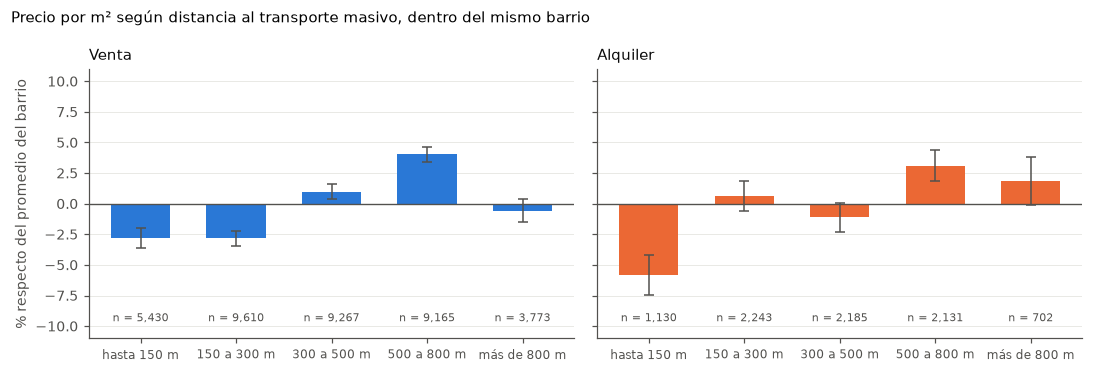

venta       alquiler      
               pct  size      pct  size
tramo                                  
hasta 150 m   -2.8  5430     -5.8  1130
150 a 300 m   -2.8  9610      0.6  2243
300 a 500 m    1.0  9267     -1.1  2185
500 a 800 m    4.0  9165      3.1  2131
más de 800 m  -0.6  3773      1.8   702

In [21]:
h3b = terr[(terr['fuente_norm'] != 'airbnb') & terr['coords_en_caba'] & terr['precio_m2_usd'].notna() & ~terr[F_M2]
           & terr['tipo_operacion_norm'].isin(['venta', 'alquiler'])].copy()
h3b['lp'] = np.log(h3b['precio_m2_usd'])
h3b['lp_vs_barrio'] = h3b['lp'] - h3b.groupby(['tipo_operacion_norm', 'barrio_oficial'])['lp'].transform('mean')
h3b['tramo'] = pd.cut(h3b['dist_transporte_masivo_m'], [0, 150, 300, 500, 800, 5000], include_lowest=True,
                      labels=['hasta 150 m', '150 a 300 m', '300 a 500 m', '500 a 800 m', 'más de 800 m'])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
tramos = {}
for ax, op in zip(axes, ['venta', 'alquiler']):
    g = h3b[h3b['tipo_operacion_norm'] == op].groupby('tramo', observed=True)['lp_vs_barrio'].agg(['mean', 'sem', 'size'])
    g['pct'] = 100 * (np.exp(g['mean']) - 1)
    g['err'] = 100 * 1.96 * g['sem']
    tramos[op] = g
    ax.bar(g.index.astype(str), g['pct'], yerr=g['err'], color=eda.COLOR_OPERACION[op], width=0.62, capsize=3,
           error_kw=dict(ecolor=eda.TEXTO_2, lw=1))
    ax.axhline(0, color=eda.TEXTO_2, lw=0.9)
    for i, (pct, n) in enumerate(zip(g['pct'], g['size'])):
        ax.text(i, -9.6, f'n = {n:,}', ha='center', fontsize=7.5, color=eda.TEXTO_2)
    ax.set_title(eda.NOMBRE_OPERACION[op])
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='x', visible=False)
    ax.set_ylim(-11, 11)
axes[0].set_ylabel('% respecto del promedio del barrio')
fig.suptitle('Precio por m² según distancia al transporte masivo, dentro del mismo barrio', x=0.01, ha='left', fontsize=10)
plt.tight_layout()
plt.show()
display(pd.concat({k: v[['pct', 'size']].round(1) for k, v in tramos.items()}, axis=1))

**Interpretación.** H3 no se sostiene con estos datos. Al comparar avisos del mismo barrio y tamaño, el coeficiente de la distancia al transporte masivo es positivo, no negativo: estar 100 m más lejos se asocia con un precio por m² entre 0,8% y 1,0% mayor, con intervalos de confianza que excluyen al cero (por poco en venta). Entre los medios, solo el subte en alquiler se distingue claramente (+0,7% por 100 m); tren, MetroBus, hospitales y espacios verdes tienen efectos indistinguibles de cero. El efecto es chico: 500 m más lejos equivalen a un 4–5% de diferencia, y los tramos muestran que no es monótono. Dentro de cada barrio, en venta los avisos a menos de 300 m del transporte cuestan un 3% menos que el promedio y los de 500 a 800 m un 4% más; en alquiler solo el tramo de menos de 150 m queda por debajo (-6%).

La comparación entre barrios cuenta la otra mitad de la historia. Los barrios más caros no son los mejor servidos por la red masiva: entre barrios, el precio por m² mediano y la distancia mediana al transporte se asocian de forma positiva y moderada (ver la tabla de arriba), lo opuesto de lo esperado. Sin controles, el coeficiente es parecido pero su intervalo incluye al cero, porque mezcla esa comparación entre barrios con la que ocurre dentro de cada uno.

**Conclusión parcial.** No hay evidencia de que la cercanía al transporte masivo se asocie con un mayor precio por m²; si algo, la señal tiene el signo contrario y es pequeña. Explicaciones plausibles, que este análisis no puede distinguir: las propiedades más cercanas al subte y al MetroBus están sobre avenidas, con más ruido y tránsito; los edificios nuevos y de mayor categoría se ubican en calles interiores; y el precio publicado no es el de cierre. Las distancias son en línea recta y la geocodificación cubre el 86% de los avisos de Mercado Libre, con un sesgo posible hacia las direcciones que informan altura.

## 8. H4 - Alquiler temporario y alquiler permanente

**Hipótesis.** Los barrios con más alojamiento temporario tienen menor disponibilidad relativa de alquiler permanente y precios residenciales más altos.

**Datos y unidad.** Comuna (15 unidades) con denominadores del Censo. **Control.** Ninguno: con 15 observaciones y datos agregados no hay forma de controlar centralidad sin sobreajustar, así que el análisis es descriptivo. Las asociaciones entre agregados no se pueden trasladar a viviendas individuales.

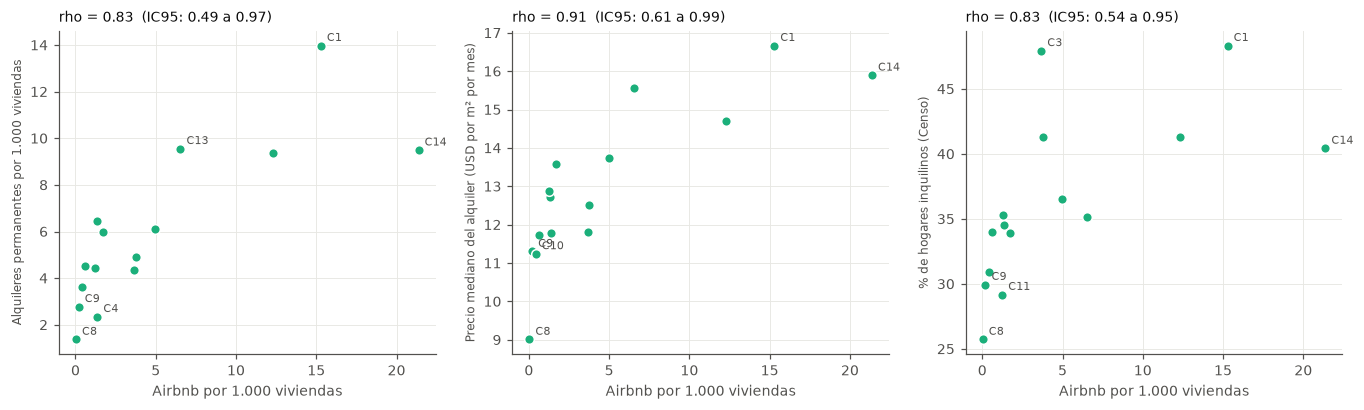

,variable,rho,lo,hi,p,n
0,Alquileres permanentes por 1.000 viviendas,0.832,0.486,0.971,0.0,15
1,Precio mediano del alquiler (USD por m² por mes),0.907,0.615,0.989,0.0,15
2,% de hogares inquilinos (Censo),0.829,0.538,0.946,0.0,15


In [22]:
pm2_alq = terr[(terr['tipo_operacion_norm'] == 'alquiler') & ~terr[F_M2]].groupby('comuna_oficial')['precio_m2_usd'].median()
h4 = kc.set_index('comuna')[['airbnb_por_1000_viviendas', 'alquiler_por_1000_viviendas', 'pct_hogares_inquilinos']].copy()
h4['pm2_alquiler_mediano'] = pm2_alq

pares = [('alquiler_por_1000_viviendas', 'Alquileres permanentes por 1.000 viviendas'),
         ('pm2_alquiler_mediano', 'Precio mediano del alquiler (USD por m² por mes)'),
         ('pct_hogares_inquilinos', '% de hogares inquilinos (Censo)')]
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))
filas = []
for ax, (col, etq) in zip(axes, pares):
    r = eda.spearman_boot(h4['airbnb_por_1000_viviendas'], h4[col], N_BOOT, SEED)
    filas.append({'variable': etq, **r})
    ax.scatter(h4['airbnb_por_1000_viviendas'], h4[col], s=40, color=eda.COLOR_OPERACION['alquiler_temporal'],
               edgecolor='white', linewidth=1, zorder=3)
    eda.rotular_extremos(ax, h4['airbnb_por_1000_viviendas'], h4[col], h4.index.astype(int), k=2, prefijo='C')
    ax.set_xlabel('Airbnb por 1.000 viviendas')
    ax.set_ylabel(etq, fontsize=8)
    ax.set_title(f'rho = {r["rho"]:.2f}  (IC95: {r["lo"]:.2f} a {r["hi"]:.2f})', fontsize=9)
plt.tight_layout()
plt.show()
h4_tabla = pd.DataFrame(filas).round(3)
display(h4_tabla)
h4_tabla.to_csv(REPORTS / 'eda08_h4_correlaciones.csv', index=False)

**Interpretación.** La hipótesis tiene dos partes y los datos las separan. **Precios:** hay apoyo. Las comunas con más Airbnb por 1.000 viviendas tienen alquileres más caros por m² (rho 0,91, la asociación más fuerte de todo el análisis). **Disponibilidad:** no hay apoyo, y el signo es contrario. Las comunas con más Airbnb tienen *más* alquileres permanentes publicados por 1.000 viviendas (0,83), no menos, y más hogares inquilinos (0,83).

Estas dos lecturas no son contradictorias: reflejan que donde hay actividad inmobiliaria hay más de todo. El alquiler publicado mide intensidad del mercado, no disponibilidad de viviendas para residentes. El centro y el norte concentran a la vez más oferta temporaria, más oferta permanente, más inquilinos y precios más altos.

**Conclusión parcial.** H4 no puede evaluarse con estos datos. La asociación positiva de los precios con la densidad de Airbnb es esperable, pero está confundida con la centralidad, y la comparación de disponibilidad no distingue entre "el temporario desplaza al permanente" y "ambos se ubican donde hay demanda". Para acercarse a esa pregunta haría falta evidencia a nivel de vivienda o de variación en el tiempo, que un corte transversal no ofrece.

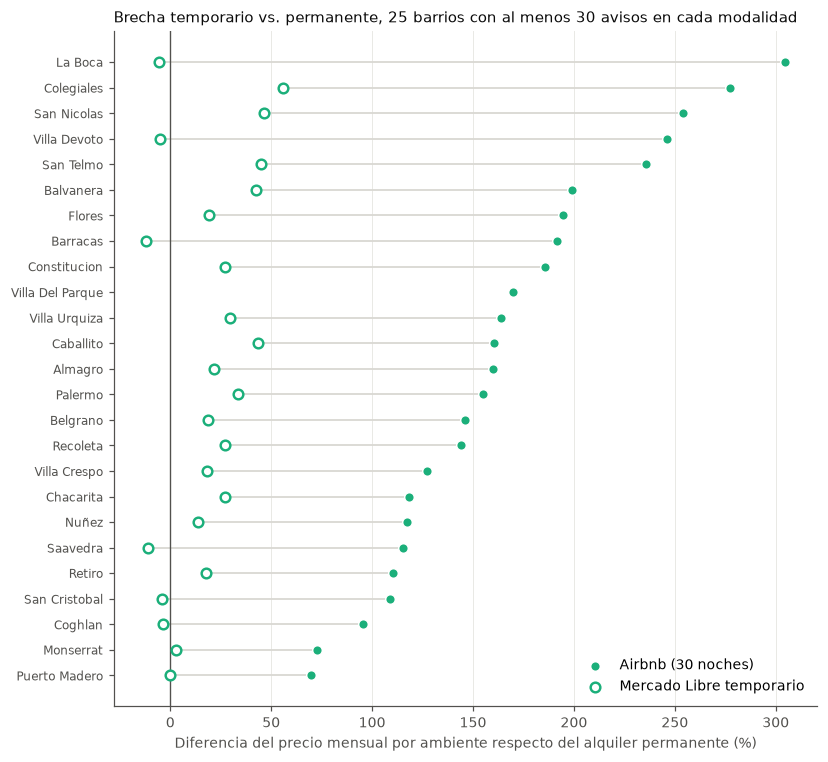

,brecha_airbnb_vs_permanente_pct,brecha_meli_temporario_vs_permanente_pct
count,25.0,32.0
mean,165.0,13.2
std,62.2,20.4
min,69.6,-25.9
25%,117.5,-3.5
50%,160.0,11.3
75%,194.7,27.1
max,304.8,55.8


In [23]:
b25 = kb.dropna(subset=['brecha_airbnb_vs_permanente_pct']).sort_values('brecha_airbnb_vs_permanente_pct')
y = np.arange(len(b25))
fig, ax = plt.subplots(figsize=(7.6, 7))
ax.hlines(y, b25['brecha_meli_temporario_vs_permanente_pct'].fillna(b25['brecha_airbnb_vs_permanente_pct']),
          b25['brecha_airbnb_vs_permanente_pct'], color='#d9d8d3', lw=1.2, zorder=1)
ax.scatter(b25['brecha_airbnb_vs_permanente_pct'], y, s=40, color=eda.COLOR_OPERACION['alquiler_temporal'],
           edgecolor='white', linewidth=1, label='Airbnb (30 noches)', zorder=3)
ax.scatter(b25['brecha_meli_temporario_vs_permanente_pct'], y, s=40, facecolor='white', linewidth=1.6,
           edgecolor=eda.COLOR_OPERACION['alquiler_temporal'], label='Mercado Libre temporario', zorder=3)
ax.axvline(0, color=eda.TEXTO_2, lw=0.9)
ax.set_yticks(y)
ax.set_yticklabels(b25['barrio_oficial'], fontsize=8)
ax.set_xlabel('Diferencia del precio mensual por ambiente respecto del alquiler permanente (%)')
ax.set_title(f'Brecha temporario vs. permanente, {len(b25)} barrios con al menos {N_MINIMO} avisos en cada modalidad')
ax.legend(loc='lower right')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()
display(kb[['brecha_airbnb_vs_permanente_pct', 'brecha_meli_temporario_vs_permanente_pct']].describe().round(1))

**Interpretación.** La brecha entre el alquiler temporario y el permanente depende por completo de la fuente que se elija. Con Airbnb, el precio mensual por ambiente es en promedio 165% mayor que el del alquiler permanente (mediana de los barrios 160%, entre 70% y 305%), y la brecha es positiva en los 25 barrios con datos. Con Mercado Libre temporario, la brecha mediana es de solo 11% (de -26% a +56%) y en 9 de los 32 barrios es negativa. Esta diferencia no es un matiz: hay que decidir en el equipo cuál de las dos fuentes representa al "alquiler temporario" o reportar siempre las dos. Además, las brechas con Airbnb están sobreestimadas como medida de costo real para el inquilino: el temporario suele venir amoblado y con servicios, el permanente no incluye expensas y los precios de Airbnb excluyen las tarifas de limpieza y de servicio.

## 9. Síntesis

In [24]:
def fila(tabla, nombre, col='variable'):
    return tabla.loc[tabla[col] == nombre].iloc[0]


c_b, g_b = fila(h1_barrio, etq_barrio['densidad_culturales_km2']), fila(h1_barrio, etq_barrio['densidad_gastronomia_km2'])
c_c = fila(h1_comuna, etq_comuna['dens_culturales'])
h3v = h3_tabla[(h3_tabla['operación'] == 'venta') & (h3_tabla['medio'] == 'Transporte masivo (mínimo de los tres)')].iloc[0]
h3a = h3_tabla[(h3_tabla['operación'] == 'alquiler') & (h3_tabla['medio'] == 'Transporte masivo (mínimo de los tres)')].iloc[0]
r_alq = fila(h4_tabla, pares[0][1])
r_pre = fila(h4_tabla, pares[1][1])

sintesis = pd.DataFrame([
    ['H1', 'Atractivo turístico y alquiler temporario', 'barrio (48) y comuna (15)',
     f"Cultura rho = {c_b['rho']:.2f} (barrio) y {c_c['rho']:.2f} (comuna); gastronomía rho = {g_b['rho']:.2f} (barrio)",
     'Evidencia a favor', 'Confundida con la centralidad (el subte también se asocia); no causal'],
    ['H2a', 'Tamaño del hogar y tipología', 'comuna (15)',
     'rho entre -0,50 y 0,01 según operación; IC incluyen el cero', 'Sin evidencia',
     'Poco poder (15 comunas); aproximación débil al hogar unipersonal; solo departamentos'],
    ['H2b', 'Servicios y oferta', 'comuna (15)',
     'Alquiler por 1.000 viviendas: cultura 0,69, gastronomía 0,66, subte 0,54; escuelas, hospitales y verdes sin relación; venta sin relación',
     'Evidencia parcial', 'Sin corrección por comparaciones múltiples; los servicios asociados son los de centralidad'],
    ['H3', 'Transporte y precio', 'publicación (~45.000)',
     f"Efecto por 100 m más lejos: venta {h3v['efecto']:+.1f}% (IC {h3v['lo']:.1f} a {h3v['hi']:.1f}), alquiler {h3a['efecto']:+.1f}% (IC {h3a['lo']:.1f} a {h3a['hi']:.1f})",
     'Sin apoyo (signo contrario, efecto pequeño)', 'Distancia en línea recta; geocodificación del 86% de los avisos de MeLi; confusión con avenidas y calidad de la unidad'],
    ['H4', 'Temporario, disponibilidad y precio', 'comuna (15)',
     f"Airbnb vs. precio del alquiler rho = {r_pre['rho']:.2f}; vs. alquileres por 1.000 viviendas rho = {r_alq['rho']:.2f} (positivo)",
     'No evaluable', 'Los precios acompañan pero por centralidad; la disponibilidad no disminuye; corte transversal con 15 unidades'],
], columns=['hipotesis', 'tema', 'unidad', 'evidencia', 'lectura', 'limitaciones'])
display(sintesis)
sintesis.to_csv(REPORTS / 'eda08_sintesis_hipotesis_v1.csv', index=False)

,hipotesis,tema,unidad,evidencia,lectura,limitaciones
0,H1,Atractivo turístico y alquiler temporario,barrio (48) y comuna (15),Cultura rho = 0.85 (barrio) y 0.86 (comuna); g...,Evidencia a favor,Confundida con la centralidad (el subte tambié...
1,H2a,Tamaño del hogar y tipología,comuna (15),"rho entre -0,50 y 0,01 según operación; IC inc...",Sin evidencia,Poco poder (15 comunas); aproximación débil al...
2,H2b,Servicios y oferta,comuna (15),"Alquiler por 1.000 viviendas: cultura 0,69, ga...",Evidencia parcial,Sin corrección por comparaciones múltiples; lo...
3,H3,Transporte y precio,publicación (~45.000),Efecto por 100 m más lejos: venta +0.8% (IC 0....,"Sin apoyo (signo contrario, efecto pequeño)",Distancia en línea recta; geocodificación del ...
4,H4,"Temporario, disponibilidad y precio",comuna (15),Airbnb vs. precio del alquiler rho = 0.91; vs....,No evaluable,Los precios acompañan pero por centralidad; la...


### Principales hallazgos
1. **El alquiler temporario es la operación más concentrada.** Palermo aporta el 30% de los avisos y tres barrios reúnen el 54% de Airbnb, mientras que la venta está repartida (ningún barrio supera el 6%).
2. **El precio por m² varía mucho entre barrios y lo hace de forma parecida en venta y alquiler** (6,3 veces y 3,1 veces; correlación entre barrios de 0,86).
3. **El "alquiler temporario" no es una sola cosa.** Airbnb cuesta 2,4 veces más que el temporario de Mercado Libre, y la brecha mediana con el alquiler permanente es de 160% con Airbnb y de 11% con Mercado Libre.
4. **La oferta cultural y gastronómica acompaña a la oferta temporaria** de forma fuerte y consistente entre unidades de análisis (H1).
5. **La cercanía al transporte no se asocia con precios más altos** una vez que se compara dentro del barrio (H3).

### Problemas de calidad detectados
- Un aviso de cada cinco declara un barrio distinto del que corresponde a su ubicación geocodificada (notebook 06); ArgenProp tiene el nombre de la calle en el campo de barrio.
- La moneda es un marcador de segmento: los alquileres publicados en USD son unidades más grandes y más caras por m² que los publicados en pesos.
- Los ambientes de Airbnb se derivan de los dormitorios y los dormitorios casi no existen en Mercado Libre; se usó el precio por ambiente en lugar del precio por dormitorio.
- Los atributos de los avisos (balcón, terraza, pileta, etc.) no están en la base consolidada, por lo que no se pudo calcular la prima por amenity.

### Decisiones de limpieza adoptadas
Se asignó el barrio por polígono cuando hay coordenadas y por texto cuando no; los precios se convirtieron a USD con el dólar MEP del día de extracción; se marcaron (sin eliminar) los valores fuera de rango plausible y se excluyeron de los estadísticos; las medianas por barrio exigen al menos 30 avisos; se conservaron los avisos presentes en dos operaciones, marcados con un indicador.

### Hipótesis con evidencia preliminar y hipótesis que aún no pueden evaluarse
- **Con evidencia preliminar:** H1 (a favor) y H2b (parcial, solo para el alquiler y para servicios de centralidad).
- **Sin apoyo en estos datos:** H3.
- **Sin evidencia o no evaluables:** H2a (faltan hogares unipersonales y más comunas con datos) y H4 (un corte transversal con 15 unidades no separa el desplazamiento de la coubicación).

### Limitaciones del dataset
- Es oferta publicada y no stock: la cobertura de cada portal varía por barrio y por operación.
- Mercado Libre aporta el 84% de la base y solo trae departamentos; ZonaProp y ArgenProp no alcanzan para comparaciones por barrio, y ZonaProp no tiene coordenadas.
- Hay 15 comunas con el Censo y 48 barrios con las fuentes de BA Data: las pruebas por unidad geográfica tienen poco poder y están expuestas a la falacia ecológica.
- Las distancias son en línea recta, las coordenadas de Airbnb están ofuscadas por la plataforma y el precio publicado no es el de cierre.
- Corte transversal y observacional: nada de lo anterior es causal.

### Próximos pasos
1. **Controlar la centralidad** en H1, H2b y H4 con un modelo multivariado a nivel barrio (por ejemplo, distancia al microcentro como control) y evaluar si las asociaciones sobreviven.
2. **Decidir con el equipo qué fuente de temporario usar** y fijar el criterio para la brecha.
3. **Recuperar los atributos de los avisos** desde los datos crudos de Mercado Libre y Airbnb para calcular la prima por amenity.
4. **Ampliar la cobertura de ZonaProp y ArgenProp** para tener comparaciones por barrio sin depender de una sola fuente.
5. **Reformular H2a y H4** con hogares unipersonales por comuna (Encuesta Anual de Hogares) y con una pregunta que un corte transversal pueda responder.
6. **Pasar a la etapa de modelado**: precio por m² con barrio, superficie, ambientes y entorno, y segmentación de barrios.